In [3]:
import json
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import(classification_report, confusion_matrix, roc_auc_score, roc_curve)
tf.random.set_seed(42)
np.random.seed(42)




In [4]:
#Train, validate and test the data loaded
train_df = pd.read_csv('malaria_train.csv')
test_df = pd.read_csv('malaria_test.csv')
val_df = pd.read_csv('malaria_val.csv')



X_train = train_df.drop(columns=['Malaria_Positive']).values.astype(np.float32)
y_train = train_df["Malaria_Positive"].values.astype(np.float32)

X_val = val_df.drop(columns=['Malaria_Positive']).values.astype(np.float32)
y_val = val_df['Malaria_Positive'].values.astype(np.float32)

X_test = test_df.drop(columns=['Malaria_Positive']).values.astype(np.float32)
y_test = test_df['Malaria_Positive'].values.astype(np.float32)

print(f'Train: {X_train.shape}')
print(f'Val: {X_val.shape}')
print(f'Test: {X_test.shape}')
print(f'Number of features: {X_train.shape[1]}')

FileNotFoundError: [Errno 2] No such file or directory: 'malaria_train.csv'

In [ ]:
with open ('malaria_train.json') as f:
  data = json.load(f)
df = pd.DataFrame(data)
target = 'Malaria_Positive'
feature = [
    col for col in df.columns
    if col !=target
]
X = df[feature].values.astype(np.float32)
y = df[target].values.astype(np.float32)

print('Loaded malaria dataset')
print(f'Number of features: {len(feature)}')
print(f'Features: {feature}')
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

In [ ]:
def build_ann(No_features):
   inputs = keras.Input(shape=(No_features,), name='features')

 #X = keras.layers.Dense(128, kernel_regularizer = keras.regularizers.l2(1e-4))(inputs)
 #X = keras.layers.Activation('relu')(x)
  #X = keras.layers.Dropout(0.3)(x)

  #X = keras.layers.Dense(64, kernel_regularizer = keras.regularizers.l2(1e-4))(x)
  #X = keras.layers.BatchNormalization()(x)
  #X = keras.layers.Activation('relu')(x)
  #X = keras.layers.Dropout(0.3)(x)

  #X = keras.layers.Dense(64)(x)
  #X = keras.layers.Activation('relu')(x)
  #X = keras.layers.Dropout(0.2)(x)

  #outputs = keras.layers.Dense(1, activation='sigmoid', name='prob')(x)
  #return keras.Model(inputs, outputs, name='malariaANN')


   x = keras.layers.Dense(128,kernel_regularizer=keras.regularizers.l2(1e-4))(inputs)
   x = keras.layers.BatchNormalization()(x)
   x = keras.layers.Activation('relu')(x)
   x = keras.layers.Dropout(0.3)(x)

   x = keras.layers.Dense(64,kernel_regularizer=keras.regularizers.l2(1e-4))(x)

   x = keras.layers.BatchNormalization()(x)
   x = keras.layers.Activation('relu')(x)
   x = keras.layers.Dropout(0.3)(x)

   x = keras.layers.Dense(64)(x)
   x = keras.layers.Activation('relu')(x)
   x = keras.layers.Dropout(0.2)(x)

   outputs = keras.layers.Dense(1,activation='sigmoid',name='prob')(x)

   return keras.Model(inputs,outputs,name='malariaANN')




In [40]:
model = build_ann(X_train.shape[1])
model.summary()

Model: "malariaANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prob (Dense)                    │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,297 (59.75 KB)

 Trainable params: 14,913 (58.25 KB)

 Non-trainable params: 384 (1.50 KB)

In [41]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss = 'binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
    ]
)

In [45]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',patience=25,

        restore_best_weights=True, mode='max', verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        'best_malaria_model.keras', monitor='val_loss',
        save_best_only = True, mode='max', verbose=0
    ),
]

In [49]:
#history=model.fit(
 #  epochs = 300, batch_size=32,
  #  validation_date=(X_val, y_val),
   # callbacks = callbacks, verbose=1,)
#print(f'\nEpochs run: {len(history.history['loss'])}')
#print(f'best val AUC: {max(history.history['val_loss']):.4f}')


history = model.fit(
    X_train,
    y_train,
    epochs=300,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

print(f"\nEpochs run: {len(history.history['loss'])}")

print(f"Best val loss: {max(history.history['val_loss']):.4f}")

Epoch 1/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8125 - auc: 0.8890 - loss: 0.4642 - precision: 0.8168 - recall: 0.7082 - val_accuracy: 0.9500 - val_auc: 0.9937 - val_loss: 0.3927 - val_precision: 0.9074 - val_recall: 0.9800
Epoch 2/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9268 - auc: 0.9757 - loss: 0.2586 - precision: 0.9103 - recall: 0.9142 - val_accuracy: 0.9583 - val_auc: 0.9960 - val_loss: 0.2347 - val_precision: 0.9245 - val_recall: 0.9800
Epoch 3/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9554 - auc: 0.9906 - loss: 0.1707 - precision: 0.9483 - recall: 0.9442 - val_accuracy: 0.9583 - val_auc: 0.9969 - val_loss: 0.1621 - val_precision: 0.9245 - val_recall: 0.9800
Epoch 4/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9750 - auc: 0.9961 - loss: 0.1227 - precision: 0.9782 - recall: 0.9614 - val_accuracy: 0.9667 - val_auc: 0.9974 - val_loss: 0.1270 - val_precision: 0.9423 - val_recall: 0.9800
Epoch 5/300
18/18 ━━━━━━━━━━━━━━

In [50]:
import matplotlib.pyplot as plt
model.load_weights('best_malaria_model.keras')
test_results = model.evaluate(X_test, y_test, verbose=0)
for name, value in zip(model.metrics_names, test_results):
  print(f'{name:<12}: {value:.4f}')

loss        : 0.5810
compile_metrics: 0.9417


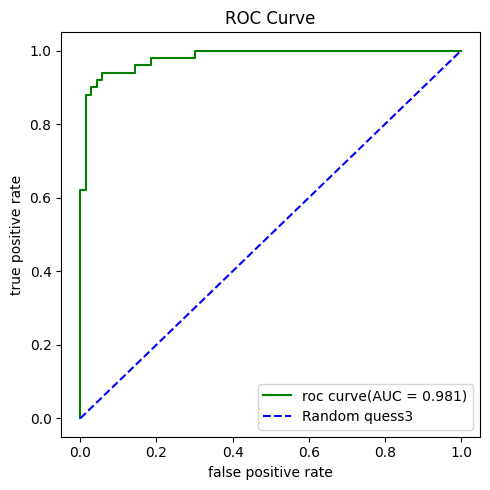

ROC-AUC: 0.9811


In [51]:
y_prob = model.predict(X_test, verbose = 0).flatten()
auc_score = roc_auc_score(y_test, y_prob)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize = (5, 5))
plt.plot(fpr, tpr, color='green', label=f'roc curve(AUC = {auc_score:.3f})')
plt.plot([0,1],[0,1], color='blue', linestyle='--', label='Random quess3')
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve_png', dpi=150, bbox_inches='tight')
plt.show()

print(f'ROC-AUC: {auc_score:.4f}')

              precision    recall  f1-score   support

  No malaria       0.93      0.97      0.95        70
     malaria       0.96      0.90      0.93        50

    accuracy                           0.94       120
   macro avg       0.94      0.94      0.94       120
weighted avg       0.94      0.94      0.94       120



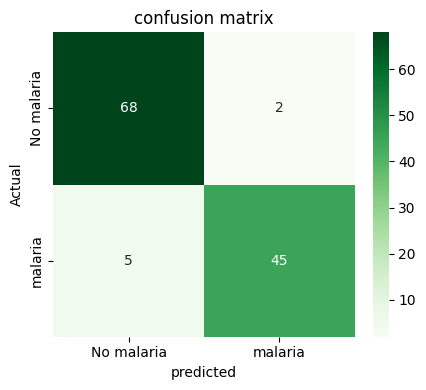

In [52]:
y_pred = (y_prob >= 0.5).astype(int)
from sklearn.preprocessing import StandardScaler
import seaborn as sns

print(classification_report(y_test, y_pred, target_names=['No malaria', 'malaria']))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No malaria', 'malaria'],
            yticklabels=['No malaria', 'malaria'])
plt.ylabel("Actual")
plt.xlabel("predicted")
plt.title('confusion matrix')
plt.tight_layout()
plt.savefig('confusion_matrix_formalaria.png', dpi=150, bbox_inches = 'tight')
plt.show()

In [53]:
model.save('malaria_ann.keras')
with open('malaria_inference_kit.pk1', 'wb') as f:
  pickle.dump({
      'feature': feature,
  }, f)
print('saved malaria_ann.keras')
print('saved malaria_inference_kit.pk1')

saved malaria_ann.keras
saved malaria_inference_kit.pk1
